# Project 1: Linear Regression from Scratch (NumPy only)

**Rules of the game:**
- No `sklearn` for modeling — only NumPy for the actual math.
- `sklearn` is allowed for: loading the California Housing dataset, and the final validation comparison in Section 5.
- All TODOs are yours to fill in. Signatures, docstrings, and structure are scaffolded for you.

**Sections**
1. Data loading & preprocessing
2. From-scratch `LinearRegressionGD` implementation
3. Training + loss curve (synthetic data)
4. Multi-feature extension (California Housing)
5. Sklearn validation
6. (Stretch) Normal Equation


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Allowed sklearn usage: data loading + final validation only
from sklearn.datasets import fetch_california_housing

# Set a seed for reproducibility across the notebook
RNG_SEED = 42
np.random.seed(RNG_SEED)

Matplotlib is building the font cache; this may take a moment.


## 1. Data Loading & Preprocessing

### 1.1 Synthetic dataset: `y = 3x + 5 + noise`

In [17]:
def generate_synthetic_data(n_samples=200, true_w=3.0, true_b=5.0, noise_std=1.0, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-10, 10, size=(n_samples, 1))
    noise = rng.normal(0, noise_std, size=n_samples)
    y = true_w * X.flatten() + true_b + noise
    return X, y

### 1.2 Real dataset: California Housing (data only)

In [18]:
def load_california_housing_data():
    data = fetch_california_housing()
    X = data.data
    y = data.target
    feature_names = list(data.feature_names)
    return X, y, feature_names

### 1.3 Manual train/test split (no `train_test_split`)

In [19]:
def train_test_split_manual(X, y, test_size=0.2, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    n_samples = X.shape[0]
    indices = rng.permutation(n_samples)
    split_point = int(n_samples * (1 - test_size))

    train_idx, test_idx = indices[:split_point], indices[split_point:]

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    return X_train, X_test, y_train, y_test

### 1.4 Manual standardization (mean/std)

In [20]:
def standardize_fit(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std[std == 0] = 1.0  # avoid div-by-zero for constant features
    return mean, std


def standardize_transform(X, mean, std):
    return (X - mean) / std

## 2. From-Scratch Implementation: `LinearRegressionGD`

This is the core of the project. Implement linear regression trained via
batch gradient descent, with optional L2 (Ridge) regularization.

Recall the math you'll need to implement:
- Prediction: `y_pred = X @ w + b`
- MSE loss: `(1/n) * sum((y_true - y_pred)^2)`, optionally + L2 penalty `alpha * sum(w^2)`
  (note: bias `b` is typically NOT regularized)
- Gradients of the (regularized) MSE loss w.r.t. `w` and `b`
- Parameter update: `w -= lr * dw`, `b -= lr * db`


In [21]:
class LinearRegressionGD:
    def __init__(self, alpha: float = 0.0):
        self.alpha = alpha
        self.w = None
        self.b = None
        self.loss_history = []

    def predict(self, X):
        return X @ self.w + self.b

    def compute_loss(self, y_true, y_pred):
        mse = np.mean((y_true - y_pred) ** 2)
        if self.alpha > 0:
            mse += self.alpha * np.sum(self.w ** 2)
        return mse

    def compute_gradients(self, X, y_true, y_pred):
        n = X.shape[0]
        error = y_pred - y_true  # shape (n,)

        dw = (2 / n) * (X.T @ error)
        db = (2 / n) * np.sum(error)

        if self.alpha > 0:
            dw += 2 * self.alpha * self.w

        return dw, db

    def fit(self, X, y, lr=0.01, epochs=1000, verbose=False):
        n_features = X.shape[1]
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.loss_history = []

        for epoch in range(epochs):
            y_pred = self.predict(X)
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)

            dw, db = self.compute_gradients(X, y, y_pred)
            self.w -= lr * dw
            self.b -= lr * db

            if verbose and epoch % max(1, epochs // 10) == 0:
                print(f"Epoch {epoch}: loss = {loss:.4f}")

        return self

## 3. Training + Loss Curve (Synthetic Data)

Train your `LinearRegressionGD` model on the synthetic `y = 3x + 5 + noise` data,
track the loss per epoch, and plot it.


In [24]:
X_syn, y_syn = generate_synthetic_data()
X_train, X_test, y_train, y_test = train_test_split_manual(X_syn, y_syn)

mean, std = standardize_fit(X_train)
X_train_scaled = standardize_transform(X_train, mean, std)
X_test_scaled = standardize_transform(X_test, mean, std)

model = LinearRegressionGD(alpha=0.0)
model.fit(X_train_scaled, y_train, lr=0.1, epochs=500, verbose=True)

print("Learned w:", model.w, "Learned b:", model.b)

Epoch 0: loss = 299.5484
Epoch 50: loss = 0.8782
Epoch 100: loss = 0.8782
Epoch 150: loss = 0.8782
Epoch 200: loss = 0.8782
Epoch 250: loss = 0.8782
Epoch 300: loss = 0.8782
Epoch 350: loss = 0.8782
Epoch 400: loss = 0.8782
Epoch 450: loss = 0.8782
Learned w: [16.72712347] Learned b: 4.344363450467883


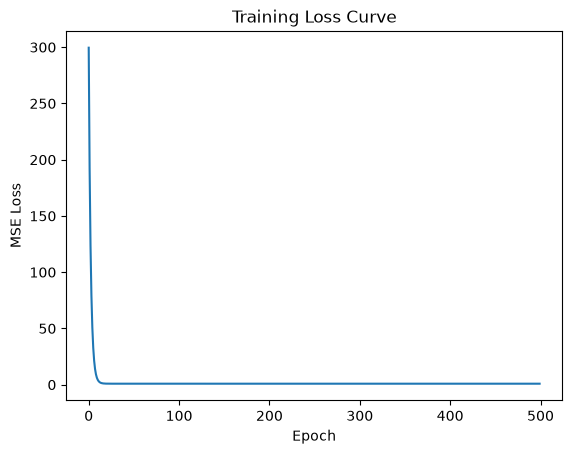

In [25]:
plt.plot(model.loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.show()

### 3.1 Learning rate experiments

Manually try learning rates `0.001`, `0.01`, `0.1` (and feel free to push further,
e.g. `1.0`, to deliberately see divergence). For each, train a fresh model and
plot the loss curve. Observe and write a short note on what you see:
- Which LR converges smoothly?
- Which is slow?
- Which diverges (loss increasing or exploding to NaN/inf)?


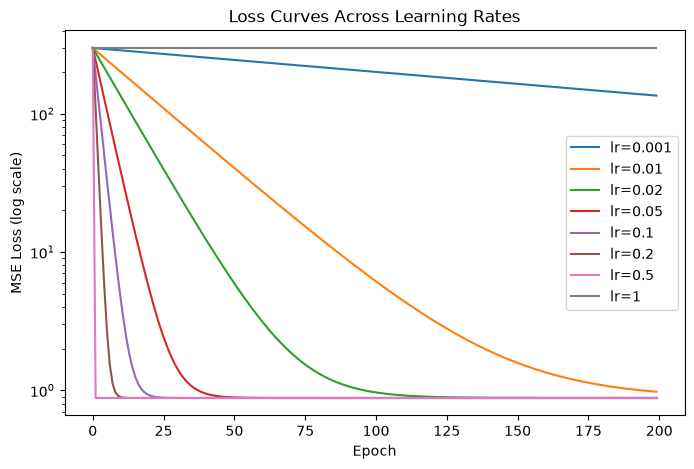

In [50]:
learning_rates = [0.001,0.01, 0.02, 0.05, 0.1,0.2,
                  \1]
histories = {}

for lr in learning_rates:
    m = LinearRegressionGD(alpha=0.0)
    m.fit(X_train_scaled, y_train, lr=lr, epochs=200)
    histories[lr] = m.loss_history

plt.figure(figsize=(8, 5))
for lr, hist in histories.items():
    plt.plot(hist, label=f"lr={lr}")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log scale)")
plt.legend()
plt.title("Loss Curves Across Learning Rates")
plt.show()

In [27]:
# TODO:
# 1. Load data via load_california_housing_data()
# 2. Split into train/test via train_test_split_manual()
# 3. Standardize features (fit on train, transform both) -- this matters
#    A LOT here since California Housing features are on very different
#    scales (e.g. median income vs average rooms vs latitude).
# 4. Train two models:
#       - model_no_reg = LinearRegressionGD(alpha=0.0)
#       - model_with_reg = LinearRegressionGD(alpha=<pick a value, e.g. 1.0>)
#    Use a learning rate / epoch count that gives stable convergence
#    (refer back to your Section 3 experiments for intuition).


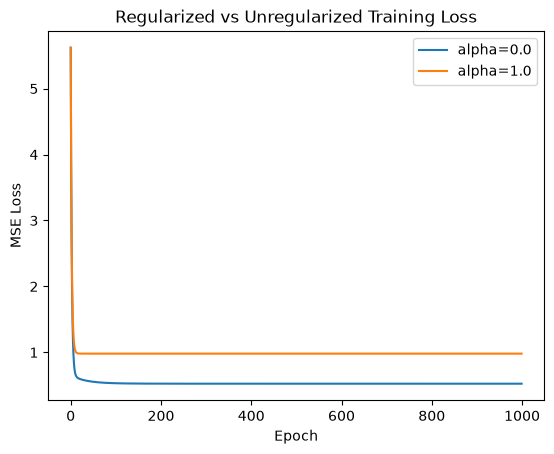

No reg weights: [ 0.81615546  0.116919   -0.23990017  0.28695682 -0.00543938 -0.03961199
 -0.91653533 -0.88842938]
With reg weights: [ 0.38904042  0.0819804   0.04667455 -0.02690802 -0.00394934 -0.01734318
 -0.09752366 -0.06497097]
Test MSE (no reg): 0.5249110850829618
Test MSE (with reg): 0.8172015900712318


In [28]:
plt.plot(model_no_reg.loss_history, label="alpha=0.0")
plt.plot(model_with_reg.loss_history, label="alpha=1.0")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("Regularized vs Unregularized Training Loss")
plt.show()

print("No reg weights:", model_no_reg.w)
print("With reg weights:", model_with_reg.w)

test_pred_no_reg = model_no_reg.predict(X_test_ch_scaled)
test_pred_with_reg = model_with_reg.predict(X_test_ch_scaled)

print("Test MSE (no reg):", np.mean((y_test_ch - test_pred_no_reg) ** 2))
print("Test MSE (with reg):", np.mean((y_test_ch - test_pred_with_reg) ** 2))

## 5. Sklearn Validation

Now (and only now) bring in `sklearn.linear_model.LinearRegression` to validate
your from-scratch implementation. Compare:
- Final learned weights/bias
- Predictions on the test set
- R² score


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sklearn_model = LinearRegression()
sklearn_model.fit(X_train_ch_scaled, y_train_ch)

my_pred = model_no_reg.predict(X_test_ch_scaled)
sklearn_pred = sklearn_model.predict(X_test_ch_scaled)



In [32]:
print("Weight diff (L2 norm):", np.linalg.norm(model_no_reg.w - sklearn_model.coef_))
print("Bias diff:", abs(model_no_reg.b - sklearn_model.intercept_))
print("My model R^2:", r2_score(y_test_ch, my_pred))
print("Sklearn R^2:", r2_score(y_test_ch, sklearn_pred))

Weight diff (L2 norm): 6.2995960672321e-05
Bias diff: 8.881784197001252e-16
My model R^2: 0.6100490336031841
Sklearn R^2: 0.6100479830884313


## 6. (Stretch) Normal Equation

Closed-form solution: `w* = (X^T X)^-1 X^T y` (with a bias term folded into X via
an added column of ones, or handled separately -- your choice).

Compare against your gradient descent solution: how do the final weights compare,
and how does "convergence speed" (one matrix solve vs many GD iterations) compare?


In [33]:
def normal_equation(X, y):
    n = X.shape[0]
    X_aug = np.hstack([np.ones((n, 1)), X])  # bias column first
    w_full = np.linalg.solve(X_aug.T @ X_aug, X_aug.T @ y)
    b, w = w_full[0], w_full[1:]
    return w, b

In [34]:
import time

start = time.time()
w_ne, b_ne = normal_equation(X_train_ch_scaled, y_train_ch)
ne_time = time.time() - start

start = time.time()
model_gd = LinearRegressionGD(alpha=0.0)
model_gd.fit(X_train_ch_scaled, y_train_ch, lr=0.1, epochs=1000)
gd_time = time.time() - start

print(f"Normal Equation time: {ne_time:.5f}s")
print(f"Gradient Descent time: {gd_time:.5f}s")
print("Weight diff (GD vs Normal Eq):", np.linalg.norm(model_gd.w - w_ne))
print("Bias diff:", abs(model_gd.b - b_ne))

Normal Equation time: 0.00393s
Gradient Descent time: 0.16466s
Weight diff (GD vs Normal Eq): 6.299596073596286e-05
Bias diff: 1.1546319456101628e-14
